In [1]:
import pandas as pd

In [2]:
FOLD = 0

In [3]:
flat_windowd_df = pd.read_csv(f"/scratch1/smaruj/genomic_flat_loci/flat_regions_tsv/fold{FOLD}_selected_genomic_windows_centered.tsv", sep="\t")

In [4]:
flat_windowd_df 

,chrom,start,end,fold,PearsonR,flat_start,flat_end,centered_start,centered_end,centered_flat_start,centered_flat_end
0,chr1,37793792,39104512,fold0,0.861165,195.0,323.0,37799936,39110656,192,320
1,chr11,65921024,67231744,fold0,0.746112,76.0,199.0,65677312,66988032,195,317
2,chr3,38414336,39725056,fold0,0.670098,198.0,422.0,38524928,39835648,144,368
3,chr3,40978432,42289152,fold0,0.754782,82.0,182.0,40724480,42035200,206,306
4,chr3,51795968,53106688,fold0,0.855747,247.0,416.0,51949568,53260288,172,340
5,chr3,53106688,54417408,fold0,0.672787,275.0,414.0,53286912,54597632,187,325
6,chr3,81006592,82317312,fold0,0.690577,56.0,250.0,80795648,82106368,159,353
7,chr3,99229696,100540416,fold0,0.684073,56.0,242.0,99010560,100321280,163,349
8,chr3,101851136,103161856,fold0,0.681364,206.0,315.0,101859328,103170048,202,310
9,chr3,105455616,106766336,fold0,0.776279,276.0,390.0,105613312,106924032,199,313


In [5]:
chromhmm_df = pd.read_csv("/home1/smaruj/mESC_mm10_3states_H3K27ac_9ac_9me3_chromHMM.bed", sep="\t", header=None)

In [6]:
chromhmm_df.columns = [
    "chrom",        # Column 1: Chromosome
    "start",        # Column 2: Start coordinate (0-based)
    "end",          # Column 3: End coordinate (exclusive)
    "state",        # Column 4: ChromHMM state (1, 2, or 3)
    "score",        # Column 5: Score (usually 0)
    "strand",       # Column 6: Strand (usually '.')
    "thickStart",   # Column 7: For browser display
    "thickEnd",     # Column 8: For browser display
    "rgb"           # Column 9: Color code for genome browser
]

In [7]:
state_map = {
    1: "active",
    2: "neutral",
    3: "repressive"
}
chromhmm_df["state_label"] = chromhmm_df["state"].map(state_map)

In [8]:
import bioframe as bf

In [9]:
flat_windowd_df = flat_windowd_df.rename(columns={"start": "og_start", "end": "og_end"})

In [10]:
cropping = 64
bin_size = 2048

In [11]:
# calculating genomic coordinates of flat regions
flat_windowd_df["start"] = flat_windowd_df["centered_start"] + (flat_windowd_df["centered_flat_start"] + cropping) * bin_size
flat_windowd_df["end"] = flat_windowd_df["centered_start"] + (flat_windowd_df["centered_flat_end"] + cropping) * bin_size

In [12]:
overlap_df = bf.overlap(
    flat_windowd_df,
    chromhmm_df,
    return_index=True,
    suffixes=("_query", "_chromhmm")
)

In [13]:
result = overlap_df[["chrom_query", 
                     "fold_query",
                     "PearsonR_query", 
                     "centered_start_query", 
                     "centered_end_query",
                     "centered_flat_start_query", 
                     "centered_flat_end_query", 
                     "state_chromhmm", 
                     "state_label_chromhmm"
]]

In [14]:
grouped = result.groupby(["chrom_query", 
                     "fold_query",
                     "PearsonR_query", 
                     "centered_start_query", 
                     "centered_end_query",
                     "centered_flat_start_query", 
                     "centered_flat_end_query", 
                     "state_chromhmm", 
                     "state_label_chromhmm"]).size().reset_index(name="count")

In [15]:
pivoted = grouped.pivot_table(
    index=["chrom_query", 
                     "fold_query",
                     "PearsonR_query", 
                     "centered_start_query", 
                     "centered_end_query",
                     "centered_flat_start_query", 
                     "centered_flat_end_query"],
    columns="state_label_chromhmm",
    values="count",
    fill_value=0
).reset_index()

In [16]:
pivoted.columns.name = None
pivoted = pivoted.rename(columns={
    "active": "active_count",
    "neutral": "neutral_count",
    "repressive": "repressive_count"
})

In [17]:
pivoted["total"] = pivoted[["active_count", "neutral_count", "repressive_count"]].sum(axis=1)

In [18]:
for label in ["active", "neutral", "repressive"]:
    pivoted[f"{label}_fraction"] = pivoted[f"{label}_count"] / pivoted["total"]

In [19]:
columns_to_remove = ["active_count", "neutral_count", "repressive_count", "total"]
pivoted.drop(columns=columns_to_remove, inplace=True)

In [20]:
pivoted.rename(columns={"chrom_query": "chrom", 
                        "fold_query": "fold",
                        "PearsonR_query": "PearsonR",
                        "centered_start_query": "centered_start",
                        "centered_end_query": "centered_end",
                        "centered_flat_start_query": "centered_flat_start",
                        "centered_flat_end_query": "centered_flat_end"}, inplace=True)

In [21]:
pivoted

,chrom,fold,PearsonR,centered_start,centered_end,centered_flat_start,centered_flat_end,active_fraction,neutral_fraction,repressive_fraction
0,chr1,fold0,0.861165,37799936,39110656,192,320,0.391304,0.521739,0.086957
1,chr11,fold0,0.746112,65677312,66988032,195,317,0.333333,0.533333,0.133333
2,chr3,fold0,0.670098,38524928,39835648,144,368,0.483871,0.516129,0.000000
3,chr3,fold0,0.672787,53286912,54597632,187,325,0.360000,0.520000,0.120000
4,chr3,fold0,0.676442,119885824,121196544,154,358,0.500000,0.500000,0.000000
5,chr3,fold0,0.681364,101859328,103170048,202,310,0.371429,0.514286,0.114286
6,chr3,fold0,0.684073,99010560,100321280,163,349,0.476190,0.523810,0.000000
7,chr3,fold0,0.690577,80795648,82106368,159,353,0.473684,0.526316,0.000000
8,chr3,fold0,0.700263,127893504,129204224,190,322,0.444444,0.555556,0.000000
9,chr3,fold0,0.750709,146692096,148002816,134,378,0.444444,0.518519,0.037037


In [ ]:
# pivoted.to_csv(f"/scratch1/smaruj/genomic_flat_loci/flat_regions_chrom_states_tsv/fold{FOLD}_selected_genomic_windows_centered_chrom_states.tsv", sep="\t", index=False)

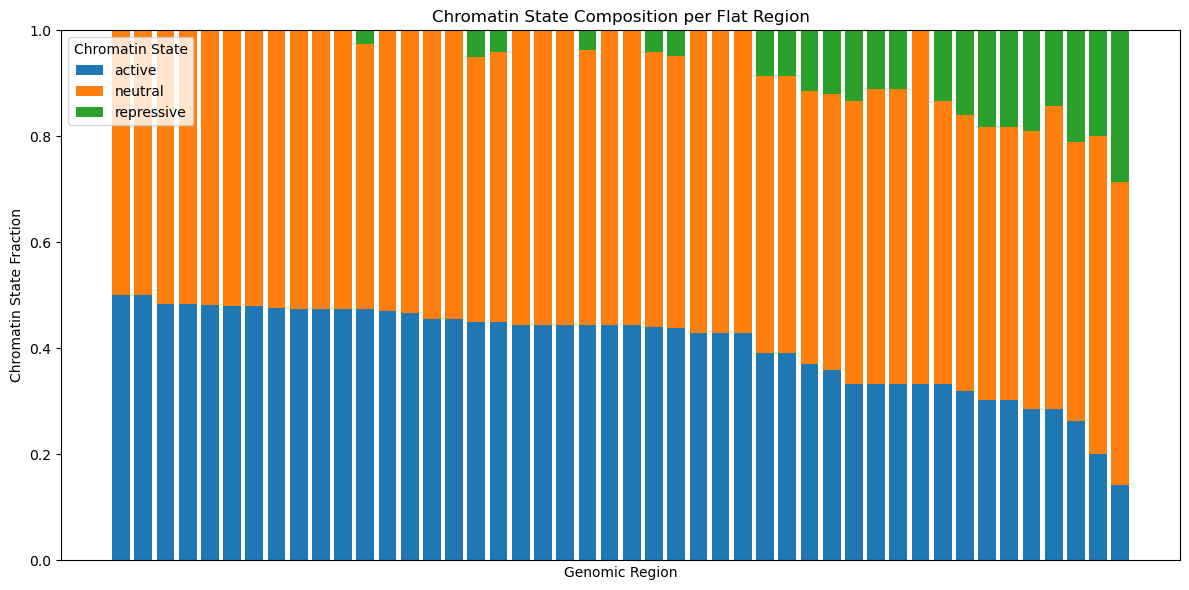

In [22]:
import matplotlib.pyplot as plt

# Sort by one of the fractions (optional)
pivoted_sorted = pivoted.sort_values("active_fraction", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
bottoms = [0] * len(pivoted_sorted)

for label, color in zip(["active", "neutral", "repressive"], [None, None, None]):
    ax.bar(
        x=range(len(pivoted_sorted)),
        height=pivoted_sorted[f"{label}_fraction"],
        bottom=bottoms,
        label=label
    )
    bottoms = [sum(x) for x in zip(bottoms, pivoted_sorted[f"{label}_fraction"])]

ax.set_xlabel("Genomic Region")
ax.set_ylabel("Chromatin State Fraction")
ax.set_title("Chromatin State Composition per Flat Region")
ax.legend(title="Chromatin State")
ax.set_xticks([])  # Optional: hide x labels if not meaningful
plt.tight_layout()
plt.show()